# Importing Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import warnings
import statsmodels.api as sm
warnings.filterwarnings('ignore')

# Loading the Dataset

In [4]:
df = pd.read_csv("C:\\Users\\user\\Desktop\\Projects\\Maximizing Taxi Revenue\\2023_Yellow_Taxi_Trip_Data.csv")


In [5]:
df = df.sample(frac = 0.05)

# Exploratory Data Analysis

In [7]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
8848338,2,03/27/2023 09:42:45 PM,03/27/2023 10:00:12 PM,1.0,8.21,1.0,N,138,141,1,33.1,6.0,0.5,4.00,0.0,1.0,48.35,2.5,1.25
3397886,2,02/04/2023 01:59:19 AM,02/04/2023 02:11:23 AM,1.0,2.46,1.0,N,148,233,1,14.2,1.0,0.5,3.84,0.0,1.0,23.04,2.5,0.00
33106916,2,11/14/2023 12:23:42 PM,11/14/2023 12:38:03 PM,1.0,0.62,1.0,N,162,161,2,12.8,0.0,0.5,0.00,0.0,1.0,16.80,2.5,0.00
2964241,2,01/31/2023 06:10:37 PM,01/31/2023 06:18:06 PM,2.0,0.53,1.0,N,264,230,1,7.9,2.5,0.5,2.88,0.0,1.0,17.28,2.5,0.00
11699313,2,04/22/2023 07:14:21 PM,04/22/2023 07:21:07 PM,1.0,0.82,1.0,N,142,142,2,7.9,0.0,0.5,0.00,0.0,1.0,11.90,2.5,0.00


In [8]:
df.shape

(1915511, 19)

In [9]:
df.dtypes

VendorID                   int64
tpep_pickup_datetime      object
tpep_dropoff_datetime     object
passenger_count          float64
trip_distance            float64
RatecodeID               float64
store_and_fwd_flag        object
PULocationID               int64
DOLocationID               int64
payment_type               int64
fare_amount              float64
extra                    float64
mta_tax                  float64
tip_amount               float64
tolls_amount             float64
improvement_surcharge    float64
total_amount             float64
congestion_surcharge     float64
airport_fee              float64
dtype: object

In [10]:
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

In [11]:
df.dtypes

VendorID                          int64
tpep_pickup_datetime     datetime64[ns]
tpep_dropoff_datetime    datetime64[ns]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
airport_fee                     float64
dtype: object

In [12]:
df['duration'] = df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
df['duration'] = df['duration'].dt.total_seconds()/60

In [13]:
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,duration
8848338,2,2023-03-27 21:42:45,2023-03-27 22:00:12,1.0,8.21,1.0,N,138,141,1,33.1,6.0,0.5,4.00,0.0,1.0,48.35,2.5,1.25,17.450000
3397886,2,2023-02-04 01:59:19,2023-02-04 02:11:23,1.0,2.46,1.0,N,148,233,1,14.2,1.0,0.5,3.84,0.0,1.0,23.04,2.5,0.00,12.066667
33106916,2,2023-11-14 12:23:42,2023-11-14 12:38:03,1.0,0.62,1.0,N,162,161,2,12.8,0.0,0.5,0.00,0.0,1.0,16.80,2.5,0.00,14.350000
2964241,2,2023-01-31 18:10:37,2023-01-31 18:18:06,2.0,0.53,1.0,N,264,230,1,7.9,2.5,0.5,2.88,0.0,1.0,17.28,2.5,0.00,7.483333
11699313,2,2023-04-22 19:14:21,2023-04-22 19:21:07,1.0,0.82,1.0,N,142,142,2,7.9,0.0,0.5,0.00,0.0,1.0,11.90,2.5,0.00,6.766667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3326146,2,2023-02-03 14:18:06,2023-02-03 14:33:07,2.0,2.03,1.0,N,142,140,1,14.9,0.0,0.5,3.78,0.0,1.0,22.68,2.5,0.00,15.016667
22927894,2,2023-08-06 17:52:52,2023-08-06 18:01:59,1.0,0.80,1.0,N,162,230,4,-9.3,0.0,-0.5,0.00,0.0,-1.0,-13.30,-2.5,0.00,9.116667
23797760,2,2023-08-16 15:47:59,2023-08-16 16:03:10,1.0,2.43,1.0,N,162,90,1,16.3,0.0,0.5,4.06,0.0,1.0,24.36,2.5,0.00,15.183333
4000698,2,2023-02-10 10:57:03,2023-02-10 11:04:44,1.0,0.86,1.0,N,161,233,2,8.6,0.0,0.5,0.00,0.0,1.0,12.60,2.5,0.00,7.683333


In [14]:
df = df[['passenger_count','trip_distance','payment_type','fare_amount','duration']]

In [15]:
df.head()

,passenger_count,trip_distance,payment_type,fare_amount,duration
8848338,1.0,8.21,1,33.1,17.450000
3397886,1.0,2.46,1,14.2,12.066667
33106916,1.0,0.62,2,12.8,14.350000
2964241,2.0,0.53,1,7.9,7.483333
11699313,1.0,0.82,2,7.9,6.766667


In [16]:
df.isnull().sum()

passenger_count    65323
trip_distance          0
payment_type           0
fare_amount            0
duration               0
dtype: int64

In [17]:
(65267/len(df))*100

3.407289229871298

In [18]:
df.dropna(inplace=True)

In [19]:
df

,passenger_count,trip_distance,payment_type,fare_amount,duration
8848338,1.0,8.21,1,33.1,17.450000
3397886,1.0,2.46,1,14.2,12.066667
33106916,1.0,0.62,2,12.8,14.350000
2964241,2.0,0.53,1,7.9,7.483333
11699313,1.0,0.82,2,7.9,6.766667
...,...,...,...,...,...
3326146,2.0,2.03,1,14.9,15.016667
22927894,1.0,0.80,4,-9.3,9.116667
23797760,1.0,2.43,1,16.3,15.183333
4000698,1.0,0.86,2,8.6,7.683333


In [20]:
df['passenger_count'] = df['passenger_count'].astype('int64')
df['payment_type'] = df['payment_type'].astype('int64')

In [21]:
df

,passenger_count,trip_distance,payment_type,fare_amount,duration
8848338,1,8.21,1,33.1,17.450000
3397886,1,2.46,1,14.2,12.066667
33106916,1,0.62,2,12.8,14.350000
2964241,2,0.53,1,7.9,7.483333
11699313,1,0.82,2,7.9,6.766667
...,...,...,...,...,...
3326146,2,2.03,1,14.9,15.016667
22927894,1,0.80,4,-9.3,9.116667
23797760,1,2.43,1,16.3,15.183333
4000698,1,0.86,2,8.6,7.683333


In [22]:
df[df.duplicated()]

,passenger_count,trip_distance,payment_type,fare_amount,duration
27908873,1,1.20,1,10.0,8.933333
4287157,1,0.60,1,6.5,5.150000
28914080,1,1.20,1,9.3,8.100000
5842286,1,0.60,1,6.5,5.150000
21066408,1,0.70,1,7.2,5.650000
...,...,...,...,...,...
6769218,1,2.72,1,20.5,21.466667
17015055,1,1.44,1,11.4,10.033333
34127643,1,2.10,1,14.9,14.450000
23797760,1,2.43,1,16.3,15.183333


In [23]:
df.drop_duplicates(inplace=True)

In [24]:
df

,passenger_count,trip_distance,payment_type,fare_amount,duration
8848338,1,8.21,1,33.1,17.450000
3397886,1,2.46,1,14.2,12.066667
33106916,1,0.62,2,12.8,14.350000
2964241,2,0.53,1,7.9,7.483333
11699313,1,0.82,2,7.9,6.766667
...,...,...,...,...,...
8070796,1,8.82,1,40.8,31.416667
33043329,2,1.22,1,10.0,10.083333
3326146,2,2.03,1,14.9,15.016667
22927894,1,0.80,4,-9.3,9.116667


In [25]:
df['passenger_count'].value_counts(normalize=True)

passenger_count
1    0.682150
2    0.186322
3    0.051399
4    0.029670
0    0.019753
5    0.018460
6    0.012233
8    0.000012
7    0.000002
Name: proportion, dtype: float64

In [26]:
df['payment_type'].value_counts(normalize=True)

payment_type
1    0.763707
2    0.210535
4    0.018110
3    0.007649
Name: proportion, dtype: float64

In [27]:
df = df[df['payment_type']<3]
df = df[(df['passenger_count'] >0) & (df['passenger_count'] <5)]

In [28]:
df.shape

(1190875, 5)

In [29]:
df['payment_type'].replace([1,2],['Card','Cash'],inplace=True)

In [30]:
df

,passenger_count,trip_distance,payment_type,fare_amount,duration
8848338,1,8.21,Card,33.1,17.450000
3397886,1,2.46,Card,14.2,12.066667
33106916,1,0.62,Cash,12.8,14.350000
2964241,2,0.53,Card,7.9,7.483333
11699313,1,0.82,Cash,7.9,6.766667
...,...,...,...,...,...
27276807,4,1.68,Card,13.5,13.233333
8070796,1,8.82,Card,40.8,31.416667
33043329,2,1.22,Card,10.0,10.083333
3326146,2,2.03,Card,14.9,15.016667


In [31]:
df.describe()

,passenger_count,trip_distance,fare_amount,duration
count,1.190875e+06,1.190875e+06,1.190875e+06,1.190875e+06
mean,1.399626e+00,4.629493e+00,2.410688e+01,2.139166e+01
std,7.320160e-01,6.023357e+01,2.079761e+01,4.921107e+01
min,1.000000e+00,0.000000e+00,-5.000000e+02,-6.170833e+02
25%,1.000000e+00,1.370000e+00,1.140000e+01,1.015000e+01
50%,1.000000e+00,2.410000e+00,1.700000e+01,1.626667e+01
75%,2.000000e+00,5.040000e+00,2.890000e+01,2.520000e+01
max,4.000000e+00,5.682380e+04,1.916800e+03,1.002918e+04


In [32]:
df = df[df['trip_distance'] >0]
df = df[df['fare_amount'] >0]
df = df[df['duration'] >0]

In [33]:
df

,passenger_count,trip_distance,payment_type,fare_amount,duration
8848338,1,8.21,Card,33.1,17.450000
3397886,1,2.46,Card,14.2,12.066667
33106916,1,0.62,Cash,12.8,14.350000
2964241,2,0.53,Card,7.9,7.483333
11699313,1,0.82,Cash,7.9,6.766667
...,...,...,...,...,...
27276807,4,1.68,Card,13.5,13.233333
8070796,1,8.82,Card,40.8,31.416667
33043329,2,1.22,Card,10.0,10.083333
3326146,2,2.03,Card,14.9,15.016667


In [34]:
df.describe()

,passenger_count,trip_distance,fare_amount,duration
count,1.175402e+06,1.175402e+06,1.175402e+06,1.175402e+06
mean,1.399461e+00,4.675951e+00,2.414277e+01,2.142461e+01
std,7.308259e-01,6.062588e+01,2.019976e+01,4.769056e+01
min,1.000000e+00,1.000000e-02,1.000000e-02,1.666667e-02
25%,1.000000e+00,1.400000e+00,1.140000e+01,1.023333e+01
50%,1.000000e+00,2.440000e+00,1.700000e+01,1.631667e+01
75%,2.000000e+00,5.100000e+00,2.890000e+01,2.520000e+01
max,4.000000e+00,5.682380e+04,1.916800e+03,6.179400e+03


{'whiskers': [<matplotlib.lines.Line2D at 0x26de94298b0>,
 'caps': [<matplotlib.lines.Line2D at 0x26de9429e80>,
 'boxes': [<matplotlib.lines.Line2D at 0x26deaf197c0>],
 'medians': [<matplotlib.lines.Line2D at 0x26de942a4e0>],
 'fliers': [<matplotlib.lines.Line2D at 0x26de942a7e0>],
 'means': []}

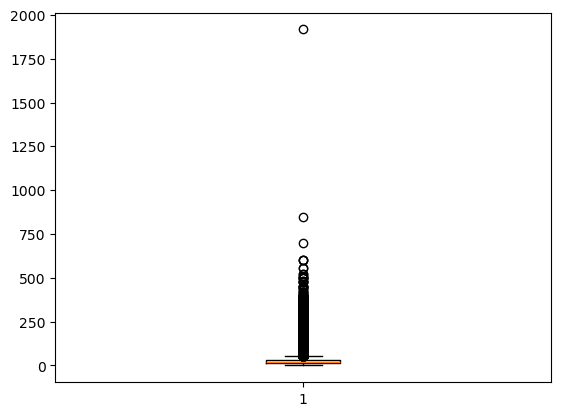

In [35]:
plt.boxplot(df['fare_amount'])

In [36]:
for col in ['trip_distance','fare_amount','duration']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    IQR = q3 - q1

    lower_bound = q1-1.5*IQR
    upper_bound = q3+1.5*IQR

    df = df[(df[col]>=lower_bound) & (df[col]<=upper_bound)]

In [37]:
df

,passenger_count,trip_distance,payment_type,fare_amount,duration
8848338,1,8.21,Card,33.1,17.450000
3397886,1,2.46,Card,14.2,12.066667
33106916,1,0.62,Cash,12.8,14.350000
2964241,2,0.53,Card,7.9,7.483333
11699313,1,0.82,Cash,7.9,6.766667
...,...,...,...,...,...
27276807,4,1.68,Card,13.5,13.233333
8070796,1,8.82,Card,40.8,31.416667
33043329,2,1.22,Card,10.0,10.083333
3326146,2,2.03,Card,14.9,15.016667


<function matplotlib.pyplot.show(close=None, block=None)>

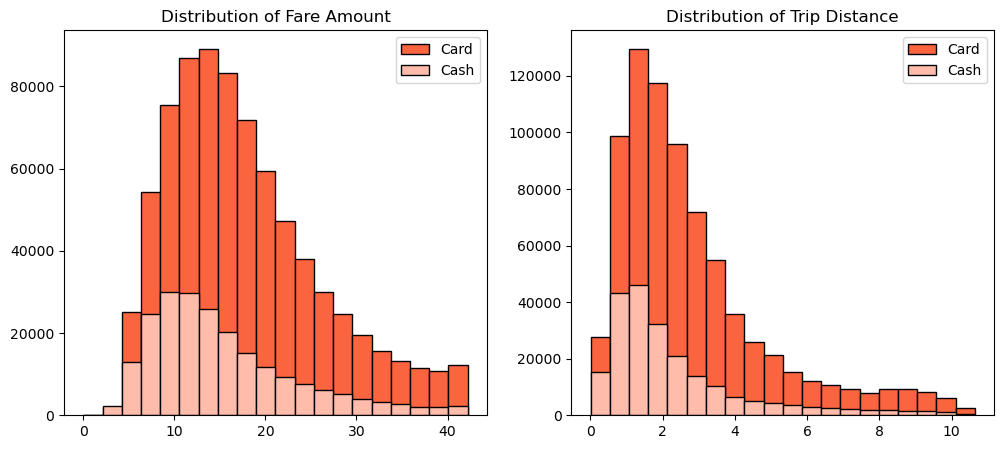

In [38]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title('Distribution of Fare Amount')
plt.hist(df[df['payment_type']=='Card']['fare_amount'], histtype = 'barstacked', bins = 20, edgecolor = 'k', color = '#FA643F', label = 'Card')
plt.hist(df[df['payment_type']=='Cash']['fare_amount'], histtype = 'barstacked', bins = 20, edgecolor = 'k', color = '#FFBCAB', label = 'Cash')
plt.legend()

plt.subplot(1,2,2)
plt.title('Distribution of Trip Distance')
plt.hist(df[df['payment_type']=='Card']['trip_distance'], histtype = 'barstacked', bins = 20, edgecolor = 'k', color = '#FA643F', label = 'Card')
plt.hist(df[df['payment_type']=='Cash']['trip_distance'], histtype = 'barstacked', bins = 20, edgecolor = 'k', color = '#FFBCAB', label = 'Cash')
plt.legend()
plt.show

In [39]:
df.groupby('payment_type').agg({'fare_amount':['mean','std'], 'trip_distance':['mean','std']})

fare_amount           trip_distance          
                    mean       std          mean       std
payment_type                                              
Card            17.52623  8.393989      2.805689  2.100209
Cash            15.17792  8.076456      2.305392  1.948683

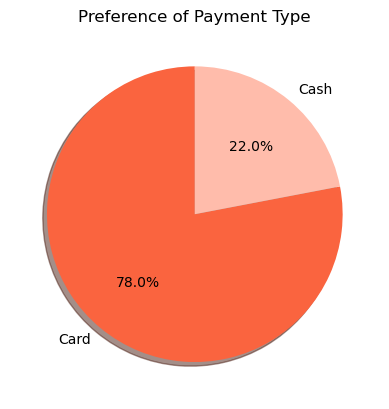

In [40]:
plt.title('Preference of Payment Type')
plt.pie(df['payment_type'].value_counts(normalize = True), labels = df['payment_type'].value_counts().index,
       startangle = 90, shadow = True, autopct = '%1.1f%%', colors = ['#FA643F','#FFBCAB'])
plt.show()

In [41]:
passenger_count = df.groupby(['payment_type','passenger_count'])[['passenger_count']].count()
passenger_count.rename(columns = {'passenger_count': 'count'}, inplace = True)
passenger_count.reset_index(inplace=True)

In [42]:
passenger_count['perc'] = (passenger_count['count']/passenger_count['count'].sum())*100

In [43]:
passenger_count

,payment_type,passenger_count,count,perc
0,Card,1,553589,56.061008
1,Card,2,151231,15.314904
2,Card,3,43189,4.373676
3,Card,4,22287,2.256966
4,Cash,1,155922,15.789953
5,Cash,2,41256,4.177924
6,Cash,3,11774,1.192333
7,Cash,4,8228,0.833235


In [44]:
df1 = pd.DataFrame(columns = ['payment_type',1,2,3,4])
df1['payment_type'] = ['Card', 'Cash']
df1.iloc[0,1:] = passenger_count.iloc[0:4,-1]
df1.iloc[1,1:] = passenger_count.iloc[4:,-1]
df1

,payment_type,1,2,3,4
0,Card,56.061008,15.314904,4.373676,2.256966
1,Cash,15.789953,4.177924,1.192333,0.833235


'"for p in ax.patches:\n    width = p.get_width()\n    height = p.get_height()\n    x, y = p.get_xy()\n    ax.text(x + width/2,\n           y + height/2,\n           \'{:.0f}%\'.format(width),\n           horizontalalignment=\'center\',\n           verticalalignment=\'center\')'

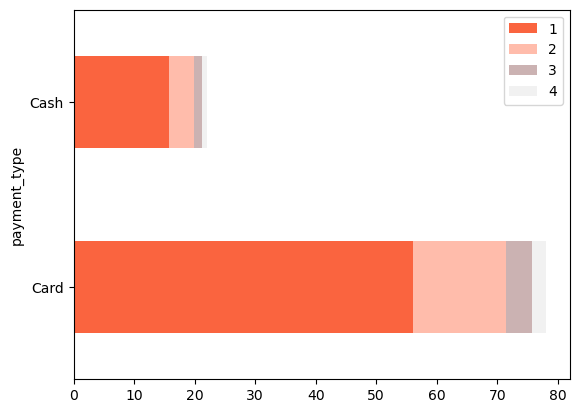

In [45]:
"fig, ax = plt.subplots(figsize=(20,6))"
df1.plot(x= 'payment_type', kind = 'barh', stacked = True, color = ['#FA643F','#FFBCAB','#CBB2B2','#F1F1F1','#FD9F9F'])

""""for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    ax.text(x + width/2,
           y + height/2,
           '{:.0f}%'.format(width),
           horizontalalignment='center',
           verticalalignment='center')"""

- __Null hypothesis:__ There is no difference in average fare between customers who use credit cards and customers who use cash.
- __Alternative hypothesis:__ There is difference in average fare between customers who use credit cards and customers who use cash.

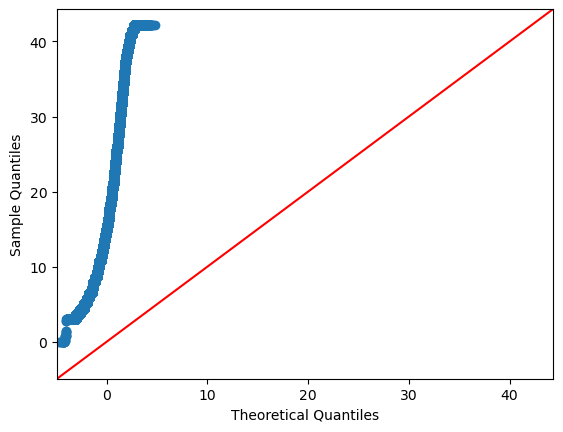

In [47]:
sm.qqplot(df['fare_amount'], line='45')
plt.show()

From the qqplot and also the histogram above it is confirmed that the data is not in normal distribution.

In [49]:
card_sample = df[df['payment_type']=='Card']['fare_amount']
cash_sample = df[df['payment_type']=='Cash']['fare_amount']

In [50]:
t_stats, p_value = st.ttest_ind(a = card_sample, b = cash_sample, equal_var = False)
print('T statistic', t_stats, 'p-value',p_value)

T statistic 118.63539134849351 p-value 0.0
